シミュレーションを開始します... (テンソル演算により高速化されています)
Step 200/1000 完了
Step 400/1000 完了
Step 600/1000 完了
Step 800/1000 完了
Step 1000/1000 完了


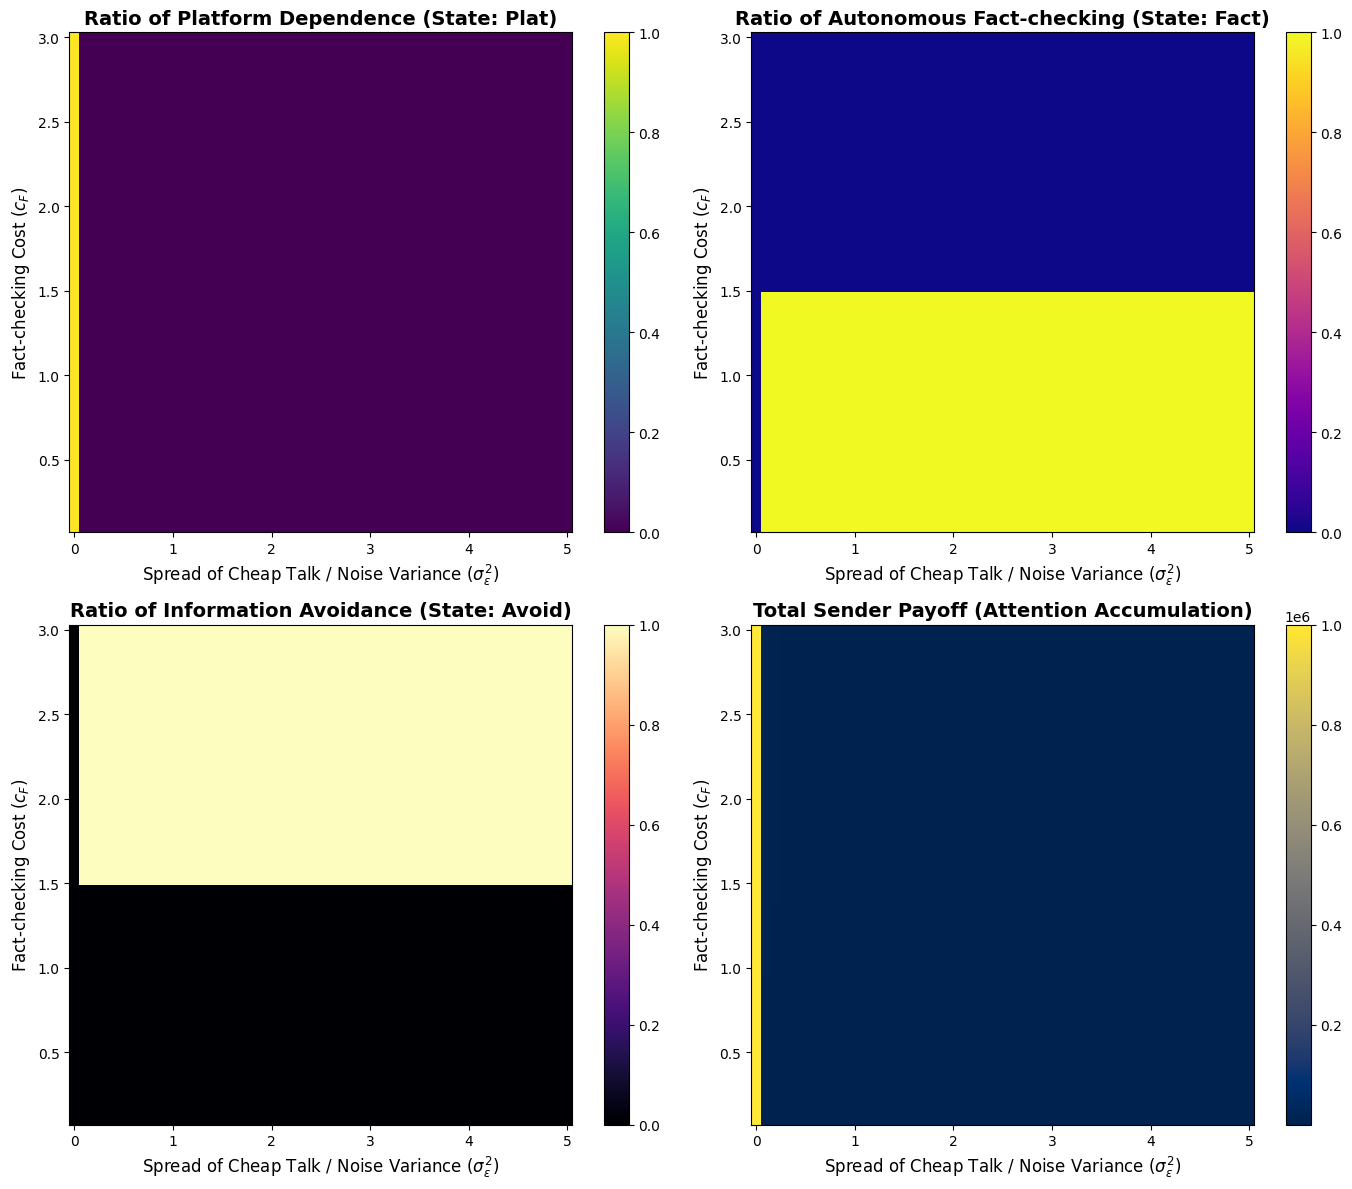

解析が完了しました。CSVファイルとグラフをZIP形式でダウンロードします。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================================================================
# 動的チープトークと情報仲介モデルの大規模マルチエージェント・シミュレーション
# Dynamic Cheap Talk and Information Intermediation Model
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

def run_simulation():
    # --------------------------------------------------------------------------
    # 1. パラメータ設定 (Parameter Settings)
    # --------------------------------------------------------------------------
    T = 1000                 # シミュレーションのステップ数
    M = 1000                 # 各グリッドにおける受信者（一般層）のエージェント数
    GRID_SIZE = 50           # グリッドサーチの解像度 (50x50)

    # X軸：チープトークの蔓延度合（ノイズ分散 sigma_eps^2）
    # 0.0（ノイズなし）から 5.0（極めてノイズが多い）まで
    sigma_eps_sq_array = np.linspace(0.0, 5.0, GRID_SIZE)

    # Y軸：ファクトチェック・コスト (c_F)
    # 0.1（容易に検証可能）から 3.0（検証が極めて困難）まで
    c_F_array = np.linspace(0.1, 3.0, GRID_SIZE)

    # モデルの定数
    rho = 0.95               # 疲労の減衰率（忘却係数）
    alpha = 1.0              # 情報の歪みに対する疲労感受性
    K = 1.5                  # 情報回避（オプトアウト）による機会損失ペナルティ

    # 疲労閾値（エージェントごとに異質性を持たせるため正規分布から抽出）
    mu_F = 2.0               # 閾値の平均
    sigma_F = 0.5            # 閾値の標準偏差

    # --------------------------------------------------------------------------
    # 2. テンソル空間の初期化 (Tensor Initialization)
    # 形状: (len(c_F), len(sigma_eps_sq), M) = (50, 50, 1000)
    # --------------------------------------------------------------------------
    # Y軸(c_F)をaxis=0、X軸(sigma_eps_sq)をaxis=1にマッピングしてブロードキャスト
    c_F_tensor = c_F_array[:, np.newaxis, np.newaxis]
    sigma_tensor = np.sqrt(sigma_eps_sq_array)[np.newaxis, :, np.newaxis]

    # エージェントの状態変数
    F = np.zeros((GRID_SIZE, GRID_SIZE, M))  # 情報的疲労 F_j(t)
    F_bar = np.random.normal(mu_F, sigma_F, (GRID_SIZE, GRID_SIZE, M)) # 許容閾値
    F_bar = np.clip(F_bar, 0.5, None)        # 閾値が負にならないようクリップ

    # エージェントの戦略状態（初期状態は全員「プラットフォーム依存」）
    state_Plat = np.ones((GRID_SIZE, GRID_SIZE, M), dtype=bool)
    state_Fact = np.zeros((GRID_SIZE, GRID_SIZE, M), dtype=bool)
    state_Avoid = np.zeros((GRID_SIZE, GRID_SIZE, M), dtype=bool)

    # プラットフォーム全体の総経済的利得を記録する配列
    total_payoff = np.zeros((GRID_SIZE, GRID_SIZE))

    print("シミュレーションを開始します... (テンソル演算により高速化されています)")

    # --------------------------------------------------------------------------
    # 3. 動的シミュレーション・ループ (Dynamic Simulation Loop)
    # --------------------------------------------------------------------------
    for t in range(T):
        # 毎期、標準正規分布に従うチープトークの誤差成分(epsilon)が発生
        # 誤差の絶対値 |s_it - omega_t| は |epsilon| に等しい
        epsilon = np.random.randn(GRID_SIZE, GRID_SIZE, M) * sigma_tensor
        abs_error = np.abs(epsilon)

        # プラットフォームに依存しているエージェントのみ疲労が蓄積・更新される
        # F_j(t+1) = rho * F_j(t) + alpha * |s_it - omega_t|
        F = np.where(state_Plat, rho * F + alpha * abs_error, F)

        # --- 戦略の移行判定 ---
        # 限界疲労閾値を超えた、またはプラットフォームの認知コスト(F)が代替手段(c_F, K)を上回った場合、離脱する
        leave_condition = (F > F_bar) | (F > c_F_tensor) | (F > K)

        # 今回新たにプラットフォームから離脱するエージェントを特定
        just_left = state_Plat & leave_condition

        if np.any(just_left):
            # プラットフォーム状態をFalseに更新
            state_Plat[just_left] = False

            # 離脱者のうち、FactとAvoidのどちらを選ぶかを利得（コスト）に基づいて決定
            # Factのコスト(c_F)がAvoidのペナルティ(K)より小さければFactを選択
            choose_fact_condition = (c_F_tensor < K)

            # ブロードキャストを用いて条件に合致するエージェントを割り振り
            # （just_leftのマスク内で条件判定）
            state_Fact = np.where(just_left & choose_fact_condition, True, state_Fact)
            state_Avoid = np.where(just_left & ~choose_fact_condition, True, state_Avoid)

        # 送信者の総アテンション（利得）を毎期加算
        total_payoff += np.sum(state_Plat, axis=2)

        if (t + 1) % 200 == 0:
            print(f"Step {t + 1}/{T} 完了")

    # --------------------------------------------------------------------------
    # 4. 結果の集計 (Aggregation)
    # --------------------------------------------------------------------------
    # 最終的な各戦略の割合を算出（エージェント軸=axis 2 で平均をとる）
    ratio_Plat = np.mean(state_Plat, axis=2)
    ratio_Fact = np.mean(state_Fact, axis=2)
    ratio_Avoid = np.mean(state_Avoid, axis=2)

    return ratio_Plat, ratio_Fact, ratio_Avoid, total_payoff, sigma_eps_sq_array, c_F_array

def save_and_plot_results(ratio_Plat, ratio_Fact, ratio_Avoid, total_payoff, X_vals, Y_vals):
    # 保存用ディレクトリの作成
    out_dir = "simulation_results"
    os.makedirs(out_dir, exist_ok=True)

    # --- CSVのエクスポート ---
    df_plat = pd.DataFrame(ratio_Plat, index=Y_vals, columns=X_vals)
    df_fact = pd.DataFrame(ratio_Fact, index=Y_vals, columns=X_vals)
    df_avoid = pd.DataFrame(ratio_Avoid, index=Y_vals, columns=X_vals)
    df_payoff = pd.DataFrame(total_payoff, index=Y_vals, columns=X_vals)

    df_plat.to_csv(f"{out_dir}/ratio_platform.csv")
    df_fact.to_csv(f"{out_dir}/ratio_fact_check.csv")
    df_avoid.to_csv(f"{out_dir}/ratio_avoidance.csv")
    df_payoff.to_csv(f"{out_dir}/total_payoff.csv")

    # --- 相図（Phase Diagram）のプロット ---
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    X, Y = np.meshgrid(X_vals, Y_vals)

    plots_info = [
        (axs[0, 0], ratio_Plat, "Ratio of Platform Dependence (State: Plat)", "viridis", [0, 1]),
        (axs[0, 1], ratio_Fact, "Ratio of Autonomous Fact-checking (State: Fact)", "plasma", [0, 1]),
        (axs[1, 0], ratio_Avoid, "Ratio of Information Avoidance (State: Avoid)", "magma", [0, 1]),
        (axs[1, 1], total_payoff, "Total Sender Payoff (Attention Accumulation)", "cividis", None)
    ]

    for ax, data, title, cmap, v_range in plots_info:
        if v_range:
            c = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto', vmin=v_range[0], vmax=v_range[1])
        else:
            c = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel(r"Spread of Cheap Talk / Noise Variance ($\sigma_\epsilon^2$)", fontsize=12)
        ax.set_ylabel(r"Fact-checking Cost ($c_F$)", fontsize=12)
        fig.colorbar(c, ax=ax)

    plt.tight_layout()
    plt.savefig(f"{out_dir}/phase_diagrams.png", dpi=300)
    plt.show()

    # --- ZIPファイル化とダウンロード ---
    shutil.make_archive(out_dir, 'zip', out_dir)
    print("解析が完了しました。CSVファイルとグラフをZIP形式でダウンロードします。")
    files.download(f"{out_dir}.zip")

# 実行ブロック
if __name__ == "__main__":
    res_plat, res_fact, res_avoid, res_payoff, x_ax, y_ax = run_simulation()
    save_and_plot_results(res_plat, res_fact, res_avoid, res_payoff, x_ax, y_ax)

シミュレーションを開始します... (テンソル演算により高速化されています)
Step 200/1000 完了
Step 400/1000 完了
Step 600/1000 完了
Step 800/1000 完了
Step 1000/1000 完了


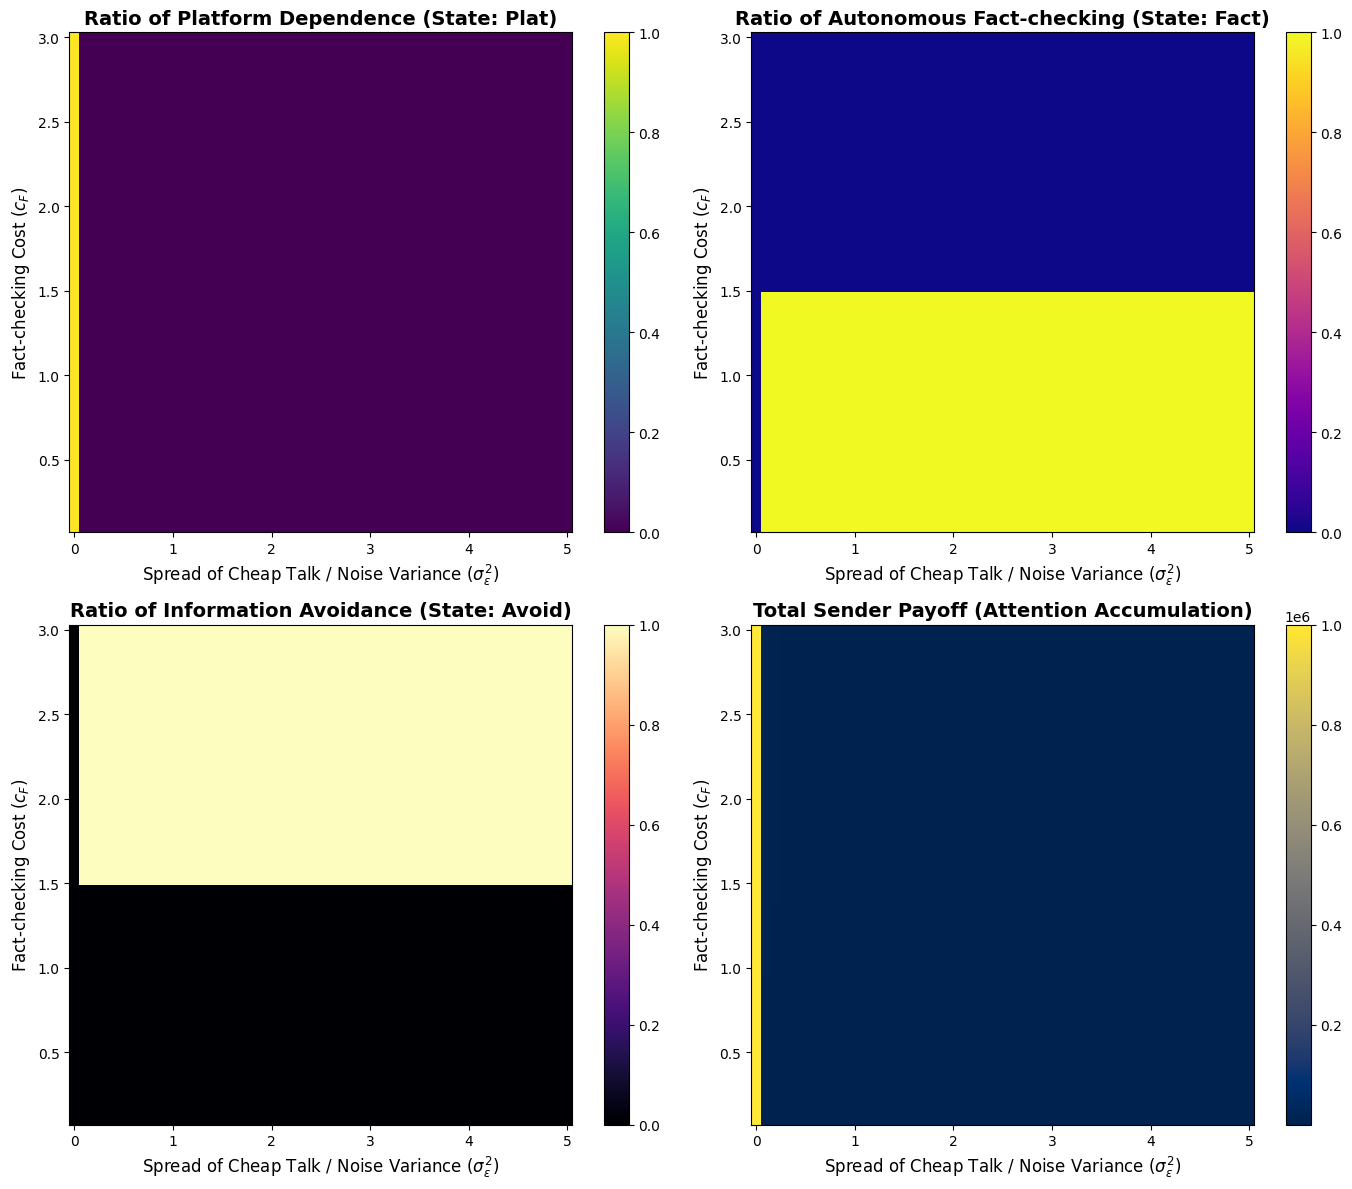

解析が完了しました。CSVファイルとグラフをZIP形式でダウンロードします。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==============================================================================
# 動的チープトークと情報仲介モデルの大規模マルチエージェント・シミュレーション
# Dynamic Cheap Talk and Information Intermediation Model
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

def run_simulation():
    # --------------------------------------------------------------------------
    # 1. パラメータ設定 (Parameter Settings)
    # --------------------------------------------------------------------------
    T = 1000                 # シミュレーションのステップ数
    M = 1000                 # 各グリッドにおける受信者（一般層）のエージェント数
    GRID_SIZE = 50           # グリッドサーチの解像度 (50x50)

    # X軸：チープトークの蔓延度合（ノイズ分散 sigma_eps^2）
    # 0.0（ノイズなし）から 5.0（極めてノイズが多い）まで
    sigma_eps_sq_array = np.linspace(0.0, 5.0, GRID_SIZE)

    # Y軸：ファクトチェック・コスト (c_F)
    # 0.1（容易に検証可能）から 3.0（検証が極めて困難）まで
    c_F_array = np.linspace(0.1, 3.0, GRID_SIZE)

    # モデルの定数
    rho = 0.95               # 疲労の減衰率（忘却係数）
    alpha = 1.0              # 情報の歪みに対する疲労感受性
    K = 1.5                  # 情報回避（オプトアウト）による機会損失ペナルティ

    # 疲労閾値（エージェントごとに異質性を持たせるため正規分布から抽出）
    mu_F = 2.0               # 閾値の平均
    sigma_F = 0.5            # 閾値の標準偏差

    # --------------------------------------------------------------------------
    # 2. テンソル空間の初期化 (Tensor Initialization)
    # 形状: (len(c_F), len(sigma_eps_sq), M) = (50, 50, 1000)
    # --------------------------------------------------------------------------
    # Y軸(c_F)をaxis=0、X軸(sigma_eps_sq)をaxis=1にマッピングしてブロードキャスト
    c_F_tensor = c_F_array[:, np.newaxis, np.newaxis]
    sigma_tensor = np.sqrt(sigma_eps_sq_array)[np.newaxis, :, np.newaxis]

    # エージェントの状態変数
    F = np.zeros((GRID_SIZE, GRID_SIZE, M))  # 情報的疲労 F_j(t)
    F_bar = np.random.normal(mu_F, sigma_F, (GRID_SIZE, GRID_SIZE, M)) # 許容閾値
    F_bar = np.clip(F_bar, 0.5, None)        # 閾値が負にならないようクリップ

    # エージェントの戦略状態（初期状態は全員「プラットフォーム依存」）
    state_Plat = np.ones((GRID_SIZE, GRID_SIZE, M), dtype=bool)
    state_Fact = np.zeros((GRID_SIZE, GRID_SIZE, M), dtype=bool)
    state_Avoid = np.zeros((GRID_SIZE, GRID_SIZE, M), dtype=bool)

    # プラットフォーム全体の総経済的利得を記録する配列
    total_payoff = np.zeros((GRID_SIZE, GRID_SIZE))

    print("シミュレーションを開始します... (テンソル演算により高速化されています)")

    # --------------------------------------------------------------------------
    # 3. 動的シミュレーション・ループ (Dynamic Simulation Loop)
    # --------------------------------------------------------------------------
    for t in range(T):
        # 毎期、標準正規分布に従うチープトークの誤差成分(epsilon)が発生
        # 誤差の絶対値 |s_it - omega_t| は |epsilon| に等しい
        epsilon = np.random.randn(GRID_SIZE, GRID_SIZE, M) * sigma_tensor
        abs_error = np.abs(epsilon)

        # プラットフォームに依存しているエージェントのみ疲労が蓄積・更新される
        # F_j(t+1) = rho * F_j(t) + alpha * |s_it - omega_t|
        F = np.where(state_Plat, rho * F + alpha * abs_error, F)

        # --- 戦略の移行判定 ---
        # 限界疲労閾値を超えた、またはプラットフォームの認知コスト(F)が代替手段(c_F, K)を上回った場合、離脱する
        leave_condition = (F > F_bar) | (F > c_F_tensor) | (F > K)

        # 今回新たにプラットフォームから離脱するエージェントを特定
        just_left = state_Plat & leave_condition

        if np.any(just_left):
            # プラットフォーム状態をFalseに更新
            state_Plat[just_left] = False

            # 離脱者のうち、FactとAvoidのどちらを選ぶかを利得（コスト）に基づいて決定
            # Factのコスト(c_F)がAvoidのペナルティ(K)より小さければFactを選択
            choose_fact_condition = (c_F_tensor < K)

            # ブロードキャストを用いて条件に合致するエージェントを割り振り
            # （just_leftのマスク内で条件判定）
            state_Fact = np.where(just_left & choose_fact_condition, True, state_Fact)
            state_Avoid = np.where(just_left & ~choose_fact_condition, True, state_Avoid)

        # 送信者の総アテンション（利得）を毎期加算
        total_payoff += np.sum(state_Plat, axis=2)

        if (t + 1) % 200 == 0:
            print(f"Step {t + 1}/{T} 完了")

    # --------------------------------------------------------------------------
    # 4. 結果の集計 (Aggregation)
    # --------------------------------------------------------------------------
    # 最終的な各戦略の割合を算出（エージェント軸=axis 2 で平均をとる）
    ratio_Plat = np.mean(state_Plat, axis=2)
    ratio_Fact = np.mean(state_Fact, axis=2)
    ratio_Avoid = np.mean(state_Avoid, axis=2)

    return ratio_Plat, ratio_Fact, ratio_Avoid, total_payoff, sigma_eps_sq_array, c_F_array

def save_and_plot_results(ratio_Plat, ratio_Fact, ratio_Avoid, total_payoff, X_vals, Y_vals):
    # 保存用ディレクトリの作成
    out_dir = "simulation_results"
    os.makedirs(out_dir, exist_ok=True)

    # --- CSVのエクスポート ---
    df_plat = pd.DataFrame(ratio_Plat, index=Y_vals, columns=X_vals)
    df_fact = pd.DataFrame(ratio_Fact, index=Y_vals, columns=X_vals)
    df_avoid = pd.DataFrame(ratio_Avoid, index=Y_vals, columns=X_vals)
    df_payoff = pd.DataFrame(total_payoff, index=Y_vals, columns=X_vals)

    df_plat.to_csv(f"{out_dir}/ratio_platform.csv")
    df_fact.to_csv(f"{out_dir}/ratio_fact_check.csv")
    df_avoid.to_csv(f"{out_dir}/ratio_avoidance.csv")
    df_payoff.to_csv(f"{out_dir}/total_payoff.csv")

    # --- 相図（Phase Diagram）のプロット ---
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    X, Y = np.meshgrid(X_vals, Y_vals)

    plots_info = [
        (axs[0, 0], ratio_Plat, "Ratio of Platform Dependence (State: Plat)", "viridis", [0, 1]),
        (axs[0, 1], ratio_Fact, "Ratio of Autonomous Fact-checking (State: Fact)", "plasma", [0, 1]),
        (axs[1, 0], ratio_Avoid, "Ratio of Information Avoidance (State: Avoid)", "magma", [0, 1]),
        (axs[1, 1], total_payoff, "Total Sender Payoff (Attention Accumulation)", "cividis", None)
    ]

    for ax, data, title, cmap, v_range in plots_info:
        if v_range:
            c = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto', vmin=v_range[0], vmax=v_range[1])
        else:
            c = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel(r"Spread of Cheap Talk / Noise Variance ($\sigma_\epsilon^2$)", fontsize=12)
        ax.set_ylabel(r"Fact-checking Cost ($c_F$)", fontsize=12)
        fig.colorbar(c, ax=ax)

    plt.tight_layout()
    plt.savefig(f"{out_dir}/phase_diagrams.png", dpi=300)
    plt.show()

    # --- ZIPファイル化とダウンロード ---
    shutil.make_archive(out_dir, 'zip', out_dir)
    print("解析が完了しました。CSVファイルとグラフをZIP形式でダウンロードします。")
    files.download(f"{out_dir}.zip")

# 実行ブロック
if __name__ == "__main__":
    res_plat, res_fact, res_avoid, res_payoff, x_ax, y_ax = run_simulation()
    save_and_plot_results(res_plat, res_fact, res_avoid, res_payoff, x_ax, y_ax)

送信者の異質性シミュレーションを開始します...
Step 200/1000 完了
Step 400/1000 完了
Step 600/1000 完了
Step 800/1000 完了
Step 1000/1000 完了


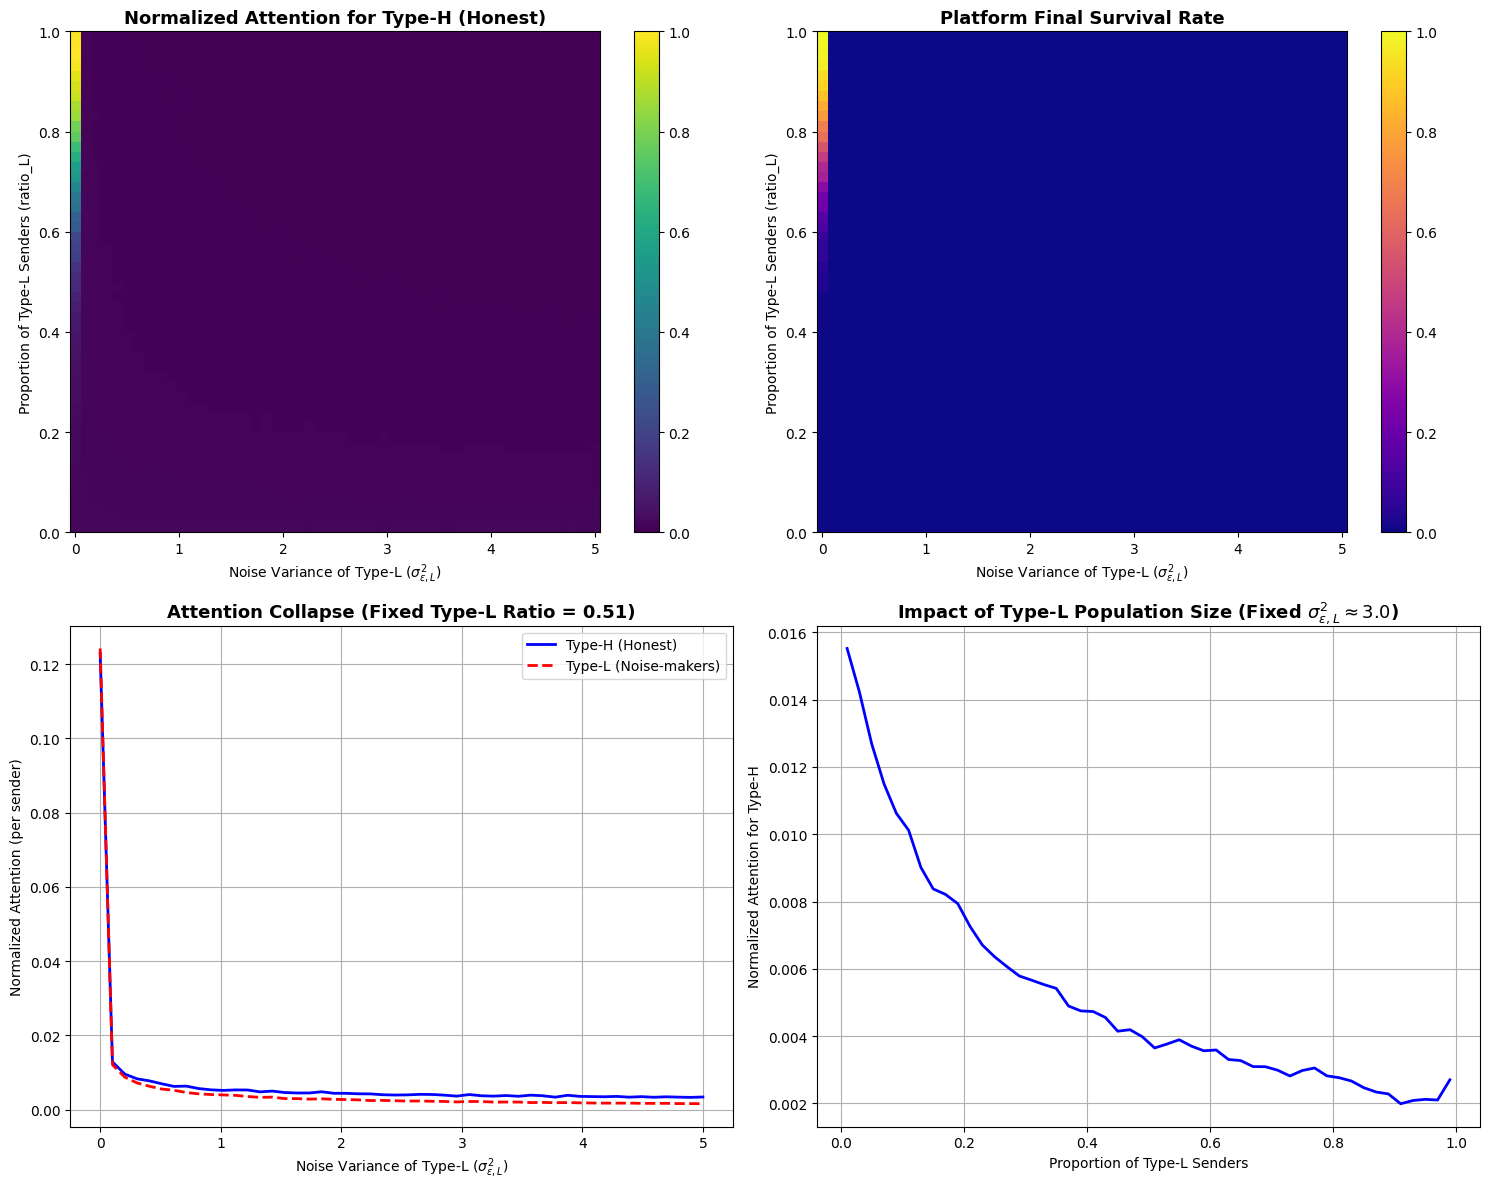

ZIPファイルの作成が完了しました。ファイルシステムの同期を待機しています...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ダウンロード命令を送信しました。ブラウザの通知を確認してください。


In [6]:
# ==============================================================================
# 送信者の異質性モデル (Heterogeneous Senders Model)
# 動的レモン市場の証明 (Proof of the Dynamic Market for Lemons)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import time
from google.colab import files

def run_heterogeneous_simulation():
    # --------------------------------------------------------------------------
    # 1. パラメータ設定 (Parameter Settings)
    # --------------------------------------------------------------------------
    T = 1000                 # シミュレーションのステップ数
    M = 1000                 # 各グリッドにおける受信者エージェント数
    GRID_SIZE = 50           # グリッドサーチの解像度 (50x50)

    # X軸：質の低い送信者(Type-L)が付加するノイズ分散 sigma_L^2 (0.0 〜 5.0)
    sigma_L_sq_array = np.linspace(0.0, 5.0, GRID_SIZE)

    # Y軸：プラットフォームにおける質の低い送信者(Type-L)の割合 (1% 〜 99%)
    # ※ 0%と100%はゼロ除算を防ぐため除外
    ratio_L_array = np.linspace(0.01, 0.99, GRID_SIZE)

    # モデルの定数
    sigma_H_sq = 0.05        # 質の高い送信者(Type-H)のノイズ分散（極めて低い固定値）
    sigma_H = np.sqrt(sigma_H_sq)
    rho = 0.95               # 疲労の減衰率
    alpha = 1.0              # 情報の歪みに対する疲労感受性

    # --------------------------------------------------------------------------
    # 2. テンソル空間の初期化 (Tensor Initialization)
    # --------------------------------------------------------------------------
    # ブロードキャスト用のテンソル変形
    ratio_L_tensor = ratio_L_array[:, np.newaxis, np.newaxis]
    sigma_L_tensor = np.sqrt(sigma_L_sq_array)[np.newaxis, :, np.newaxis]

    # エージェントの状態変数
    F = np.zeros((GRID_SIZE, GRID_SIZE, M))  # 情報的疲労 F_j(t)
    F_bar = np.random.normal(2.0, 0.5, (GRID_SIZE, GRID_SIZE, M)) # 許容閾値
    F_bar = np.clip(F_bar, 0.5, None)

    state_Plat = np.ones((GRID_SIZE, GRID_SIZE, M), dtype=bool) # プラットフォーム滞在フラグ

    # 各タイプの送信者が獲得した総アテンション
    payoff_H = np.zeros((GRID_SIZE, GRID_SIZE))
    payoff_L = np.zeros((GRID_SIZE, GRID_SIZE))

    print("送信者の異質性シミュレーションを開始します...")

    # --------------------------------------------------------------------------
    # 3. 動的シミュレーション・ループ (Dynamic Simulation Loop)
    # --------------------------------------------------------------------------
    for t in range(T):
        # 毎期、受信者は送信者をランダムにサンプリングする
        # U < ratio_L の場合は Type-L を、それ以外は Type-H を引く
        U = np.random.rand(GRID_SIZE, GRID_SIZE, M)
        picked_L = U < ratio_L_tensor

        # それぞれのタイプのノイズを発生させる
        err_H = np.random.randn(GRID_SIZE, GRID_SIZE, M) * sigma_H
        err_L = np.random.randn(GRID_SIZE, GRID_SIZE, M) * sigma_L_tensor

        # 受信者が引いた送信者に応じた誤差（チープトーク）を観測
        current_err = np.where(picked_L, err_L, err_H)

        # 疲労の蓄積（プラットフォーム滞在者のみ）
        F = np.where(state_Plat, rho * F + alpha * np.abs(current_err), F)

        # 限界疲労を超えたエージェントはプラットフォームからオプトアウト
        state_Plat = state_Plat & (F <= F_bar)

        # アテンション（利得）の集計
        # プラットフォームに残っており、かつそのタイプを引いたエージェントの数を加算
        payoff_H += np.sum(state_Plat & ~picked_L, axis=2)
        payoff_L += np.sum(state_Plat & picked_L, axis=2)

        if (t + 1) % 200 == 0:
            print(f"Step {t + 1}/{T} 完了")

    # --------------------------------------------------------------------------
    # 4. 指標の正規化 (Normalization)
    # --------------------------------------------------------------------------
    # 単純な総和ではなく、「送信者1人あたり、1ステップあたり」が
    # 最大ポテンシャルに対して何％のアテンションを獲得できたか（正規化利得）を算出
    max_possible_H = M * T * (1.0 - ratio_L_array[:, np.newaxis])
    max_possible_L = M * T * ratio_L_array[:, np.newaxis]

    norm_payoff_H = payoff_H / max_possible_H
    norm_payoff_L = payoff_L / max_possible_L
    survival_rate = np.mean(state_Plat, axis=2)

    return norm_payoff_H, norm_payoff_L, survival_rate, sigma_L_sq_array, ratio_L_array

def save_and_plot_results(norm_payoff_H, norm_payoff_L, survival_rate, X_vals, Y_vals):
    out_dir = "heterogeneous_results"
    os.makedirs(out_dir, exist_ok=True)

    # --- CSVエクスポート ---
    df_H = pd.DataFrame(norm_payoff_H, index=Y_vals, columns=X_vals)
    df_L = pd.DataFrame(norm_payoff_L, index=Y_vals, columns=X_vals)
    df_surv = pd.DataFrame(survival_rate, index=Y_vals, columns=X_vals)

    df_H.to_csv(f"{out_dir}/normalized_payoff_Type_H.csv")
    df_L.to_csv(f"{out_dir}/normalized_payoff_Type_L.csv")
    df_surv.to_csv(f"{out_dir}/platform_survival_rate.csv")

    # --- グラフ描画 ---
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    X, Y = np.meshgrid(X_vals, Y_vals)

    # (1) Type-Hの正規化利得（ヒートマップ）
    c1 = axs[0, 0].pcolormesh(X, Y, norm_payoff_H, cmap='viridis', shading='auto', vmin=0, vmax=1)
    axs[0, 0].set_title("Normalized Attention for Type-H (Honest)", fontsize=13, fontweight='bold')
    axs[0, 0].set_xlabel(r"Noise Variance of Type-L ($\sigma_{\epsilon,L}^2$)")
    axs[0, 0].set_ylabel("Proportion of Type-L Senders (ratio_L)")
    fig.colorbar(c1, ax=axs[0, 0])

    # (2) プラットフォームの最終生存率（ヒートマップ）
    c2 = axs[0, 1].pcolormesh(X, Y, survival_rate, cmap='plasma', shading='auto', vmin=0, vmax=1)
    axs[0, 1].set_title("Platform Final Survival Rate", fontsize=13, fontweight='bold')
    axs[0, 1].set_xlabel(r"Noise Variance of Type-L ($\sigma_{\epsilon,L}^2$)")
    axs[0, 1].set_ylabel("Proportion of Type-L Senders (ratio_L)")
    fig.colorbar(c2, ax=axs[0, 1])

    # (3) Type-Lが50%混在時の利得崩壊プロセス（断面図グラフ）
    mid_idx = len(Y_vals) // 2  # ratio_L ≒ 0.5 のインデックス
    axs[1, 0].plot(X_vals, norm_payoff_H[mid_idx, :], label="Type-H (Honest)", color='blue', linewidth=2)
    axs[1, 0].plot(X_vals, norm_payoff_L[mid_idx, :], label="Type-L (Noise-makers)", color='red', linestyle='--', linewidth=2)
    axs[1, 0].set_title(f"Attention Collapse (Fixed Type-L Ratio = {Y_vals[mid_idx]:.2f})", fontsize=13, fontweight='bold')
    axs[1, 0].set_xlabel(r"Noise Variance of Type-L ($\sigma_{\epsilon,L}^2$)")
    axs[1, 0].set_ylabel("Normalized Attention (per sender)")
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # (4) Type-Lのノイズ分散を3.0に固定した際の、割合に対する崩壊（断面図グラフ）
    high_noise_idx = np.abs(X_vals - 3.0).argmin()
    axs[1, 1].plot(Y_vals, norm_payoff_H[:, high_noise_idx], label="Type-H (Honest)", color='blue', linewidth=2)
    # raw文字列 (r"...") を使用してLaTeXエラーを回避
    axs[1, 1].set_title(r"Impact of Type-L Population Size (Fixed $\sigma_{\epsilon, L}^2 \approx 3.0$)", fontsize=13, fontweight='bold')
    axs[1, 1].set_xlabel("Proportion of Type-L Senders")
    axs[1, 1].set_ylabel("Normalized Attention for Type-H")
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig(f"{out_dir}/heterogeneous_dynamics.png", dpi=300)
    plt.show()

    # --- ZIP化とダウンロードの安定化 ---
    shutil.make_archive(out_dir, 'zip', out_dir)
    print("ZIPファイルの作成が完了しました。ファイルシステムの同期を待機しています...")
    time.sleep(3) # ダウンロード失敗を防ぐための待機時間

    try:
        files.download(f"{out_dir}.zip")
        print("ダウンロード命令を送信しました。ブラウザの通知を確認してください。")
    except Exception as e:
        print(f"自動ダウンロードに失敗しました。画面左側のフォルダアイコンから手動でダウンロードしてください。エラー詳細: {e}")

# ==============================================================================
# 実行ブロック
# ==============================================================================
if __name__ == "__main__":
    res_H, res_L, res_surv, x_ax, y_ax = run_heterogeneous_simulation()
    save_and_plot_results(res_H, res_L, res_surv, x_ax, y_ax)

In [7]:
# ==============================================================================
# 現代アテンション・エコノミーの高度な課題検証シミュレーション
# Task 1: アルゴリズムによる選択的接触 (Algorithmic Amplification)
# Task 2: 進化ゲーム動学による戦略適応 (Evolutionary Dynamics)
# Task 3: 制度的介入と遅延効果 (Community Notes & Maximum Tolerable Delay)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import time
from google.colab import files

def setup_directories():
    out_dir = "advanced_simulation_results"
    os.makedirs(out_dir, exist_ok=True)
    return out_dir

# ------------------------------------------------------------------------------
# Task 1: アルゴリズムによる選択的接触
# ------------------------------------------------------------------------------
def run_task1_algorithmic_amplification(out_dir):
    print("Task 1: アルゴリズムの選択的接触をシミュレート中...")
    T = 1000; M = 2000; GRID = 50
    sigma_L_sq_vals = np.linspace(0.0, 5.0, GRID)
    ratio_L = 0.5
    sigma_H = np.sqrt(0.05)

    # テンソル化 (sigma_L を次元0、エージェントを次元1)
    sigma_L_tensor = np.sqrt(sigma_L_sq_vals)[:, np.newaxis]

    def simulate_task1(use_algorithm):
        F = np.zeros((GRID, M))
        F_bar = np.random.normal(2.0, 0.5, (GRID, M)).clip(0.5, None)
        state_Plat = np.ones((GRID, M), dtype=bool)

        for t in range(T):
            if use_algorithm:
                # センセーショナルな投稿（ノイズ分散が大きい）ほどアルゴリズムがブーストする
                kappa = 1.0 # ブースト係数
                weight_L = ratio_L * (1 + kappa * sigma_L_sq_vals)
                weight_H = (1 - ratio_L) * (1 + kappa * 0.05)
                prob_L = weight_L / (weight_L + weight_H)
            else:
                prob_L = np.full(GRID, ratio_L)

            prob_L_tensor = prob_L[:, np.newaxis]
            picked_L = np.random.rand(GRID, M) < prob_L_tensor

            err_H = np.random.randn(GRID, M) * sigma_H
            err_L = np.random.randn(GRID, M) * sigma_L_tensor
            current_err = np.where(picked_L, err_L, err_H)

            F = np.where(state_Plat, 0.95 * F + 1.0 * np.abs(current_err), F)
            state_Plat = state_Plat & (F <= F_bar)

        return np.mean(state_Plat, axis=1)

    surv_base = simulate_task1(use_algorithm=False)
    surv_algo = simulate_task1(use_algorithm=True)

    df = pd.DataFrame({'Sigma_L_sq': sigma_L_sq_vals, 'Baseline_Random': surv_base, 'Algorithmic_Boost': surv_algo})
    df.to_csv(f"{out_dir}/task1_algorithmic_amplification.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(sigma_L_sq_vals, surv_base, label="Baseline (Random Sampling)", color='blue', linewidth=2)
    plt.plot(sigma_L_sq_vals, surv_algo, label="Algorithmic Amplification", color='red', linestyle='--', linewidth=2)
    plt.title("Task 1: Impact of Algorithmic Amplification on Platform Survival", fontweight='bold')
    plt.xlabel(r"Noise Variance of Type-L ($\sigma_{\epsilon,L}^2$)")
    plt.ylabel("Platform Final Survival Rate")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{out_dir}/task1_plot.png", dpi=300)
    plt.close()

# ------------------------------------------------------------------------------
# Task 2: 送信者の進化ゲーム動学 (Replicator Dynamics)
# ------------------------------------------------------------------------------
def run_task2_evolutionary_dynamics(out_dir):
    print("Task 2: 進化ゲーム動学による戦略適応をシミュレート中...")
    T = 1500; M = 5000
    ratio_L = 0.05 # 初期は質の低い送信者が5%のみ
    sigma_H = np.sqrt(0.05); sigma_L = np.sqrt(3.0)

    F = np.zeros(M)
    F_bar = np.random.normal(2.0, 0.5, M).clip(0.5, None)
    state_Plat = np.ones(M, dtype=bool)

    history_ratio_L = []; history_survival = []

    kappa = 1.0 # アルゴリズムのエンゲージメント評価係数
    learning_rate = 0.05 # 送信者の戦略更新スピード

    for t in range(T):
        history_ratio_L.append(ratio_L)
        history_survival.append(np.mean(state_Plat))

        # 1. 受信者の情報処理
        weight_L = ratio_L * (1 + kappa * (sigma_L**2))
        weight_H = (1 - ratio_L) * (1 + kappa * (sigma_H**2))
        prob_L = weight_L / (weight_L + weight_H) if (weight_L + weight_H) > 0 else ratio_L

        picked_L = np.random.rand(M) < prob_L
        err_H = np.random.randn(M) * sigma_H
        err_L = np.random.randn(M) * sigma_L
        current_err = np.where(picked_L, err_L, err_H)

        F = np.where(state_Plat, 0.95 * F + 1.0 * np.abs(current_err), F)
        state_Plat = state_Plat & (F <= F_bar)

        # 2. レプリケーター方程式による戦略適応（Type-HがType-Lへと寝返る）
        payoff_L = 1 + kappa * (sigma_L**2)
        payoff_H = 1 + kappa * (sigma_H**2)
        avg_payoff = ratio_L * payoff_L + (1 - ratio_L) * payoff_H

        # 送信者がプラットフォームに残っている聴衆を奪い合う進化動学
        ratio_L = ratio_L + learning_rate * ratio_L * (payoff_L - avg_payoff)
        ratio_L = np.clip(ratio_L, 0.01, 0.99)

    df = pd.DataFrame({'Step': range(T), 'Ratio_Type_L': history_ratio_L, 'Platform_Survival': history_survival})
    df.to_csv(f"{out_dir}/task2_evolutionary_dynamics.csv", index=False)

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(range(T), history_ratio_L, label="Proportion of Type-L", color='red', linewidth=2)
    ax1.set_xlabel("Time (Steps)")
    ax1.set_ylabel("Proportion of Type-L Senders", color='red')
    ax1.tick_params(axis='y', labelcolor='red')

    ax2 = ax1.twinx()
    ax2.plot(range(T), history_survival, label="Platform Survival", color='blue', linestyle='--', linewidth=2)
    ax2.set_ylabel("Platform Survival Rate", color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    plt.title("Task 2: Gresham's Law via Replicator Dynamics", fontweight='bold')
    fig.tight_layout()
    plt.grid(True)
    plt.savefig(f"{out_dir}/task2_plot.png", dpi=300)
    plt.close()

# ------------------------------------------------------------------------------
# Task 3: 制度的介入（コミュニティノート）の遅延効果
# ------------------------------------------------------------------------------
def run_task3_community_notes(out_dir):
    print("Task 3: コミュニティノートの遅延効果をシミュレート中...")
    T = 1000; M = 1000
    delta_vals = np.arange(0, 51, 2) # 遅延ステップ数 (0〜50)
    sigma_L_sq_vals = np.linspace(0.0, 5.0, 26)
    ratio_L = 0.5; sigma_H = np.sqrt(0.05)

    survival_matrix = np.zeros((len(delta_vals), len(sigma_L_sq_vals)))

    for i, delta in enumerate(delta_vals):
        sigma_L_tensor = np.sqrt(sigma_L_sq_vals)[:, np.newaxis]
        F = np.zeros((len(sigma_L_sq_vals), M))
        F_bar = np.random.normal(2.0, 0.5, (len(sigma_L_sq_vals), M)).clip(0.5, None)
        state_Plat = np.ones((len(sigma_L_sq_vals), M), dtype=bool)

        # 遅延回復のためのリングバッファ
        buffer_L_err = []

        for t in range(T):
            picked_L = np.random.rand(len(sigma_L_sq_vals), M) < ratio_L
            err_H = np.random.randn(len(sigma_L_sq_vals), M) * sigma_H
            err_L = np.random.randn(len(sigma_L_sq_vals), M) * sigma_L_tensor
            current_err = np.where(picked_L, err_L, err_H)

            # Type-Lのノイズ量を記録
            buffer_L_err.append(np.where(picked_L, np.abs(err_L), 0.0))

            # 疲労の蓄積
            F = np.where(state_Plat, 0.95 * F + 1.0 * np.abs(current_err), F)

            # コミュニティノートによる事後回復（deltaステップ前のダメージを無効化）
            if len(buffer_L_err) > delta:
                recovery = buffer_L_err.pop(0)
                # 注：すでに閾値を超えて離脱した者は回復できない（致命的遅延）
                F = np.maximum(0, F - 1.0 * recovery)

            # 限界疲労を超えたら即座にオプトアウト（手遅れになる）
            state_Plat = state_Plat & (F <= F_bar)

        survival_matrix[i, :] = np.mean(state_Plat, axis=1)

    df = pd.DataFrame(survival_matrix, index=delta_vals, columns=sigma_L_sq_vals)
    df.to_csv(f"{out_dir}/task3_community_notes_delay.csv")

    plt.figure(figsize=(8, 6))
    X, Y = np.meshgrid(sigma_L_sq_vals, delta_vals)
    c = plt.pcolormesh(X, Y, survival_matrix, cmap='plasma', shading='auto', vmin=0, vmax=1)
    plt.colorbar(c, label="Platform Survival Rate")
    plt.title("Task 3: Maximum Tolerable Delay of Community Notes", fontweight='bold')
    plt.xlabel(r"Noise Variance of Type-L ($\sigma_{\epsilon,L}^2$)")
    plt.ylabel(r"Fact-check Delay ($\delta$ steps)")
    plt.savefig(f"{out_dir}/task3_plot.png", dpi=300)
    plt.close()

# ------------------------------------------------------------------------------
# 実行とZIP化
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    out_dir = setup_directories()

    # 各タスクの実行
    run_task1_algorithmic_amplification(out_dir)
    run_task2_evolutionary_dynamics(out_dir)
    run_task3_community_notes(out_dir)

    # ZIP化とダウンロード
    print("すべての計算が完了しました。ZIPファイルを作成します...")
    shutil.make_archive(out_dir, 'zip', out_dir)
    time.sleep(3)

    try:
        files.download(f"{out_dir}.zip")
        print("ダウンロード命令を送信しました。")
    except Exception as e:
        print(f"自動ダウンロードに失敗しました。手動で '{out_dir}.zip' をダウンロードしてください。エラー詳細: {e}")

Task 1: アルゴリズムの選択的接触をシミュレート中...
Task 2: 進化ゲーム動学による戦略適応をシミュレート中...
Task 3: コミュニティノートの遅延効果をシミュレート中...
すべての計算が完了しました。ZIPファイルを作成します...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ダウンロード命令を送信しました。
